In [12]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st
import numpy as np
import reframed
import sys
sys.path.append('../../../code/')
import leakage
import utils

In [13]:
folder = Path('../../../data/this_project/1_e_coli_batch_cultures/')
rates_fn = folder / '1J_metabolite_rates.csv'
div_folder = Path('../../../data/this_project/5_div/')
mapping_fn = div_folder / '5A_metabolomics_name_to_bigg.csv'

In [14]:
model_ez = reframed.load_cbmodel('../../../models/e_coli/momentiJO1366_modified.xml')
model_ez.solver = 'gurobi'

In [15]:
model_e = reframed.load_cbmodel('../../../models/e_coli/iJO1366.xml')
model_e.solver = 'gurobi'

In [16]:
mapping_dict = pd.read_csv(mapping_fn, index_col = 0).to_dict()['BiGG ID']

In [17]:
cs_to_exchange = {
    'Galactose': 'R_EX_gal_e',
    'L-malate': 'R_EX_mal__L_e',
    'L-alanine': 'R_EX_ala__L_e'
}

cs_to_uptake = {
    'Galactose': -4.3,
    'L-malate': -16.5,
    'L-alanine': -17.4
}

# With enzyme constraints

In [18]:
from reframed.solvers.solution import Status

# Load rates
rates = pd.read_csv(rates_fn, header=0, skiprows=[1])

# Base: close glucose (open by default in momentiJO1366)
base_constraints = {'R_EX_glc__D_e': (0, 0)}

summary_rows = []
feasible_constraints_per_cs = {}  # store feasible constraints for shadow price analysis

for cs, cs_ex_id in cs_to_exchange.items():
    cs_rate = cs_to_uptake[cs]
    cs_data = rates[rates['Carbon source'] == cs].copy()

    print(f"\n{'='*60}")
    print(f"  {cs}  (uptake fixed at {cs_rate:.2f} mmol/gDW/h)")
    print(f"{'='*60}")

    # --- Unconstrained FBA: only fix carbon source uptake ---
    uncon_c = {**base_constraints, cs_ex_id: (cs_rate, 0)}
    sol_uncon = reframed.FBA(model_ez, constraints=uncon_c)
    growth_uncon = sol_uncon.fobj

    if growth_uncon is None:
        print(f"  Growth (unconstrained):  INFEASIBLE [{sol_uncon.status}]")
        feasible_constraints_per_cs[cs] = dict(uncon_c)
        summary_rows.append({
            'Carbon source': cs,
            'CS uptake [mmol/gDW/h]': cs_rate,
            'Growth unconstrained [h⁻¹]': None,
            'Growth constrained [h⁻¹]': None,
            'Decrease [h⁻¹]': None,
            'Decrease [%]': None,
            'N imposed': 0,
            'N skipped (infeasible)': 0,
            'Solver status': str(sol_uncon.status),
        })
        continue

    print(f"  Growth (unconstrained):  {growth_uncon:.4f} h⁻¹")

    # --- Add secretion constraints one by one, skip if infeasible ---
    con_c = dict(uncon_c)
    imposed, infeasible_skipped, skipped_no_map, skipped_not_in_model = [], [], [], []

    for _, row in cs_data.iterrows():
        met_name = row['Metabolite']
        rate = row['Rate [mmol/gDW/h]']

        if pd.isna(rate) or rate <= 0:
            continue  # only impose positive (secretion) rates

        bigg_id = mapping_dict.get(met_name)
        if not bigg_id or (isinstance(bigg_id, float) and np.isnan(bigg_id)):
            skipped_no_map.append(met_name)
            continue

        ex_id = f'R_EX_{bigg_id}_e'
        if ex_id not in model_ez.reactions:
            skipped_not_in_model.append((met_name, ex_id))
            continue

        # Test this constraint before committing
        test_c = {**con_c, ex_id: (rate, 1000)}
        sol_test = reframed.FBA(model_ez, constraints=test_c)

        if sol_test.fobj is not None:
            con_c[ex_id] = (rate, 1000)
            imposed.append((met_name, ex_id, rate))
        else:
            infeasible_skipped.append((met_name, ex_id, rate))

    # Store feasible constraints for shadow price estimation below
    feasible_constraints_per_cs[cs] = dict(con_c)

    # --- Final constrained FBA ---
    sol_con = reframed.FBA(model_ez, constraints=con_c)
    growth_con = sol_con.fobj

    decrease = (growth_uncon - growth_con) if growth_con is not None else None
    pct_decrease = (decrease / growth_uncon * 100) if (decrease is not None and growth_uncon > 0) else None

    if growth_con is not None:
        print(f"  Growth (constrained):    {growth_con:.4f} h⁻¹")
        print(f"  Decrease:                {decrease:.4f} h⁻¹  ({pct_decrease:.1f}%)")
    else:
        print(f"  Growth (constrained):    INFEASIBLE  [{sol_con.status}]")

    print(f"\n  Imposed secretion constraints ({len(imposed)}):")
    for met, ex_id, r in imposed:
        print(f"    {met:<35} {r:+.6f} mmol/gDW/h")

    if infeasible_skipped:
        print(f"\n  Skipped — infeasible individually ({len(infeasible_skipped)}):")
        for met, ex_id, r in infeasible_skipped:
            print(f"    {met:<35} {r:+.6f} mmol/gDW/h  [{ex_id}]")

    if skipped_no_map:
        print(f"\n  Skipped — no BiGG mapping ({len(skipped_no_map)}): {skipped_no_map}")
    if skipped_not_in_model:
        print(f"\n  Skipped — exchange reaction not in model ({len(skipped_not_in_model)}): {[m for m, _ in skipped_not_in_model]}")

    summary_rows.append({
        'Carbon source': cs,
        'CS uptake [mmol/gDW/h]': cs_rate,
        'Growth unconstrained [h⁻¹]': round(growth_uncon, 4),
        'Growth constrained [h⁻¹]': round(growth_con, 4) if growth_con is not None else None,
        'Decrease [h⁻¹]': round(decrease, 4) if decrease is not None else None,
        'Decrease [%]': round(pct_decrease, 1) if pct_decrease is not None else None,
        'N imposed': len(imposed),
        'N skipped (infeasible)': len(infeasible_skipped),
        'Solver status': str(sol_con.status),
    })

print(f"\n\n{'='*60}")
print("  SUMMARY")
print(f"{'='*60}")
pd.DataFrame(summary_rows).set_index('Carbon source')



  Galactose  (uptake fixed at -4.30 mmol/gDW/h)
Set parameter Username


Academic license - for non-commercial use only - expires 2026-11-28
  Growth (unconstrained):  0.4053 h⁻¹
  Growth (constrained):    0.3976 h⁻¹
  Decrease:                0.0077 h⁻¹  (1.9%)

  Imposed secretion constraints (12):
    Acetate                             +0.203725 mmol/gDW/h
    Aspartate                           +0.000121 mmol/gDW/h
    Formate                             +0.357255 mmol/gDW/h
    Gamma-aminobutyrate                 +0.000009 mmol/gDW/h
    Glutamate                           +0.001786 mmol/gDW/h
    Leucine                             +0.000085 mmol/gDW/h
    Lysine                              +0.000100 mmol/gDW/h
    Malate                              +0.000203 mmol/gDW/h
    Phenylalanine                       +0.000012 mmol/gDW/h
    Proline                             +0.000004 mmol/gDW/h
    Succinate                           +0.018379 mmol/gDW/h
    Valine                              +0.000002 mmol/gDW/h

  Skipped — infeasible individually (4

,CS uptake [mmol/gDW/h],Growth unconstrained [h⁻¹],Growth constrained [h⁻¹],Decrease [h⁻¹],Decrease [%],N imposed,N skipped (infeasible),Solver status
Carbon source,,,,,,,,
Galactose,-4.3,0.4053,0.3976,0.0077,1.9,12,4,Status.OPTIMAL
L-malate,-16.5,0.5500,0.5490,0.0010,0.2,11,3,Status.OPTIMAL
L-alanine,-17.4,0.3002,0.2697,0.0305,10.2,16,3,Status.OPTIMAL


# Now estimate metabolite values with and without imposed release rates

In [26]:
# Metabolites to estimate shadow prices for (intracellular, mapped from measurements)
measured_metabolite_ids = [f'M_{m_id}_c' for m_id in mapping_dict.values() if isinstance(m_id, str)]
measured_metabolite_ids_in_model = [m for m in measured_metabolite_ids if model_ez.metabolites.get(m)]
print(f"Metabolites in model: {len(measured_metabolite_ids_in_model)}")

sp_without = {}  # shadow prices — only carbon source constraint
sp_with    = {}  # shadow prices — carbon source + all feasible secretion constraints

for cs, cs_ex_id in cs_to_exchange.items():
    cs_rate = cs_to_uptake[cs]
    print(f"\n--- {cs} ---")

    constraints_without = {'R_EX_glc__D_e': (0, 0), cs_ex_id: (cs_rate, 0)}

    print("  Without secretion constraints...")
    sp_without[cs] = leakage.estimate_shadow_prices_reframed(
        model_ez,
        constraints=constraints_without,
        delta=0.01,
        metabolites=measured_metabolite_ids_in_model,
    )

    print("  With secretion constraints...")
    sp_with[cs] = leakage.estimate_shadow_prices_reframed(
        model_ez,
        constraints=feasible_constraints_per_cs[cs],
        delta=0.01,
        metabolites=measured_metabolite_ids_in_model,
    )

# Metabolite values = -1 * shadow price
mv_without = pd.DataFrame(sp_without) * -1
mv_with    = pd.DataFrame(sp_with)    * -1

# Difference: how much do metabolite values change when secretion is imposed?
mv_diff = mv_with - mv_without

# Shorten index labels for display (strip M_ prefix and _c suffix)
def fmt_id(m): return m[2:-2]
mv_diff.index = mv_diff.index.map(fmt_id)
mv_without.index = mv_without.index.map(fmt_id)
mv_with.index    = mv_with.index.map(fmt_id)

print("\nMetabolite values WITHOUT imposed secretion rates [gDW/mmol]:")
display(mv_without.round(5))

print("\nMetabolite values WITH imposed secretion rates [gDW/mmol]:")
display(mv_with.round(5))

# Show only metabolites whose value changes
changed = mv_diff[(mv_diff.abs() > 1e-6).any(axis=1)].sort_values('L-malate', ascending=False)
print(f"\nMetabolite value change (with − without), {len(changed)} metabolites affected:")
display(changed.round(5))


Metabolites in model: 83

--- Galactose ---
  Without secretion constraints...
  With secretion constraints...
5/83: M_ac_c, predicted flux: 0.2037245636129564, secretion reaction: R_EX_ac_e
25/83: M_for_c, predicted flux: 0.3572547265283111, secretion reaction: R_EX_for_e
30/83: M_glu__L_c, predicted flux: 0.0017859625823931, secretion reaction: R_EX_glu__L_e
70/83: M_succ_c, predicted flux: 0.0183791658781734, secretion reaction: R_EX_succ_e

--- L-malate ---
  Without secretion constraints...
5/83: M_ac_c, predicted flux: 0.32043538590849374, secretion reaction: R_EX_ac_e
48/83: M_mal__L_c, predicted flux: -15.525389391381196, secretion reaction: R_EX_mal__L_e
  With secretion constraints...
5/83: M_ac_c, predicted flux: 0.6140630198971179, secretion reaction: R_EX_ac_e
25/83: M_for_c, predicted flux: 0.0772184218873558, secretion reaction: R_EX_for_e
30/83: M_glu__L_c, predicted flux: 0.0012275255593944, secretion reaction: R_EX_glu__L_e
48/83: M_mal__L_c, predicted flux: -15.74338

,Galactose,L-malate,L-alanine
23dhb,0.10942,0.09507,0.12845
ghb,0.06369,0.02758,0.05640
34hpp,0.13761,0.08769,0.14277
ac,0.02162,0.00156,0.01347
adn,0.19155,0.22189,0.19162
...,...,...,...
ump,0.12723,0.09150,0.12053
val__L,0.09046,0.08740,0.07036
xan,0.10045,0.12905,0.09799
xtsn,0.17174,0.17615,0.17475



Metabolite values WITH imposed secretion rates [gDW/mmol]:


,Galactose,L-malate,L-alanine
23dhb,0.10942,0.09513,0.12853
ghb,0.06369,0.02760,0.05644
34hpp,0.13753,0.08774,0.14286
ac,0.02169,0.00156,0.01456
adn,0.19156,0.22204,0.19176
...,...,...,...
ump,0.12715,0.09156,0.12061
val__L,0.09046,0.08746,0.07041
xan,0.10037,0.12914,0.09805
xtsn,0.17174,0.17627,0.17487



Metabolite value change (with − without), 74 metabolites affected:


,Galactose,L-malate,L-alanine
mal__L,-0.00008,0.00044,-0.00006
nad,0.00008,0.00025,0.00024
56dura,0.00000,0.00023,0.00006
camp,-0.00008,0.00015,0.00013
adn,0.00000,0.00015,0.00014
...,...,...,...
ahcys,0.00004,-0.00078,-0.00053
met__L,-0.00000,-0.00096,-0.00095
arg__L,-0.00000,-0.00106,-0.00112
citr__L,0.00008,-0.00107,-0.00104


In [29]:
# Percentage change: (with - without) / without * 100
# Exclude zeros in denominator to avoid division artefacts
mv_pct_diff = (mv_with - mv_without) / mv_without.replace(0, np.nan) * 100

summary_pct = pd.DataFrame({
    'Mean % change': mv_pct_diff.mean(),
    'Std % change':  mv_pct_diff.std(),
    'Mean |% change|': mv_pct_diff.abs().mean(),
})
print("Percentage change in metabolite values (with vs without imposed secretion rates):")
display(summary_pct.round(4))


Percentage change in metabolite values (with vs without imposed secretion rates):


,Mean % change,Std % change,Mean |% change|
Galactose,0.0038,0.1521,0.0475
L-malate,0.0698,0.5945,0.1726
L-alanine,0.0977,0.9923,0.2374


In [38]:
np.nanmean(np.abs(mv_pct_diff.values.flatten())), np.nanstd(np.abs(mv_pct_diff.values.flatten()))

(np.float64(0.15248777516945136), np.float64(0.6551356453893703))

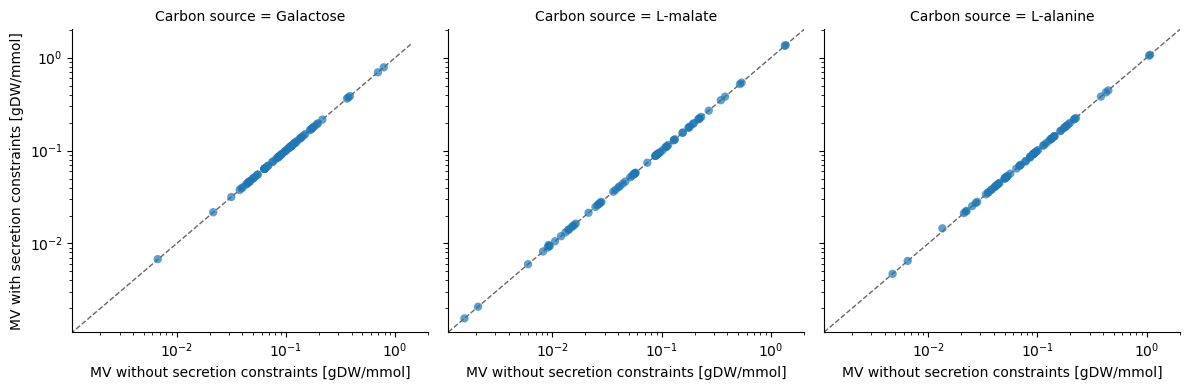

In [30]:
# Build long-form DataFrame for plotting
plot_rows = []
for cs in cs_to_exchange:
    for met in mv_without.index:
        v_without = mv_without.loc[met, cs]
        v_with    = mv_with.loc[met, cs]
        if np.isfinite(v_without) and np.isfinite(v_with) and v_without > 0 and v_with > 0:
            plot_rows.append({'Carbon source': cs, 'Metabolite': met,
                              'Without constraints': v_without,
                              'With constraints': v_with})
plot_df = pd.DataFrame(plot_rows)

g = sns.FacetGrid(plot_df, col='Carbon source', height=4, aspect=1)
g.map_dataframe(sns.scatterplot, x='Without constraints', y='With constraints',
                alpha=0.7, edgecolor='none')

# Add y = x reference line on each axis
for ax in g.axes.flat:
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, ls='--', c='0.4', lw=1, zorder=0)
    ax.set_xscale('log')
    ax.set_yscale('log')
    # Re-apply equal limits after log scale
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.set_xlim(lims); ax.set_ylim(lims)

g.set_axis_labels('MV without secretion constraints [gDW/mmol]',
                  'MV with secretion constraints [gDW/mmol]')
sns.despine()
plt.tight_layout()
plt.show()


# Without enzyme constraints

In [23]:
from reframed.solvers.solution import Status

# Load rates
rates = pd.read_csv(rates_fn, header=0, skiprows=[1])

# Base: close glucose (open by default in momentiJO1366)
base_constraints = {'R_EX_glc__D_e': (0, 0)}

summary_rows = []

for cs, cs_ex_id in cs_to_exchange.items():
    cs_rate = cs_to_uptake[cs]
    cs_data = rates[rates['Carbon source'] == cs].copy()

    print(f"\n{'='*60}")
    print(f"  {cs}  (uptake fixed at {cs_rate:.2f} mmol/gDW/h)")
    print(f"{'='*60}")

    # --- Unconstrained FBA: only fix carbon source uptake ---
    uncon_c = {**base_constraints, cs_ex_id: (cs_rate, 0)}
    sol_uncon = reframed.FBA(model_e, constraints=uncon_c)
    growth_uncon = sol_uncon.fobj

    if growth_uncon is None:
        print(f"  Growth (unconstrained):  INFEASIBLE [{sol_uncon.status}]")
        summary_rows.append({
            'Carbon source': cs,
            'CS uptake [mmol/gDW/h]': cs_rate,
            'Growth unconstrained [h⁻¹]': None,
            'Growth constrained [h⁻¹]': None,
            'Decrease [h⁻¹]': None,
            'Decrease [%]': None,
            'N imposed': 0,
            'N skipped (infeasible)': 0,
            'Solver status': str(sol_uncon.status),
        })
        continue

    print(f"  Growth (unconstrained):  {growth_uncon:.4f} h⁻¹")

    # --- Add secretion constraints one by one, skip if infeasible ---
    con_c = dict(uncon_c)
    imposed, infeasible_skipped, skipped_no_map, skipped_not_in_model = [], [], [], []

    for _, row in cs_data.iterrows():
        met_name = row['Metabolite']
        rate = row['Rate [mmol/gDW/h]']

        if pd.isna(rate) or rate <= 0:
            continue  # only impose positive (secretion) rates

        bigg_id = mapping_dict.get(met_name)
        if not bigg_id or (isinstance(bigg_id, float) and np.isnan(bigg_id)):
            skipped_no_map.append(met_name)
            continue

        ex_id = f'R_EX_{bigg_id}_e'
        if ex_id not in model_e.reactions:
            skipped_not_in_model.append((met_name, ex_id))
            continue

        # Test this constraint before committing
        test_c = {**con_c, ex_id: (rate, 1000)}
        sol_test = reframed.FBA(model_e, constraints=test_c)

        if sol_test.fobj is not None:
            con_c[ex_id] = (rate, 1000)
            imposed.append((met_name, ex_id, rate))
        else:
            infeasible_skipped.append((met_name, ex_id, rate))

    # --- Final constrained FBA ---
    sol_con = reframed.FBA(model_e, constraints=con_c)
    growth_con = sol_con.fobj

    decrease = (growth_uncon - growth_con) if growth_con is not None else None
    pct_decrease = (decrease / growth_uncon * 100) if (decrease is not None and growth_uncon > 0) else None

    if growth_con is not None:
        print(f"  Growth (constrained):    {growth_con:.4f} h⁻¹")
        print(f"  Decrease:                {decrease:.4f} h⁻¹  ({pct_decrease:.1f}%)")
    else:
        print(f"  Growth (constrained):    INFEASIBLE  [{sol_con.status}]")

    print(f"\n  Imposed secretion constraints ({len(imposed)}):")
    for met, ex_id, r in imposed:
        print(f"    {met:<35} {r:+.6f} mmol/gDW/h")

    if infeasible_skipped:
        print(f"\n  Skipped — infeasible individually ({len(infeasible_skipped)}):")
        for met, ex_id, r in infeasible_skipped:
            print(f"    {met:<35} {r:+.6f} mmol/gDW/h  [{ex_id}]")

    if skipped_no_map:
        print(f"\n  Skipped — no BiGG mapping ({len(skipped_no_map)}): {skipped_no_map}")
    if skipped_not_in_model:
        print(f"\n  Skipped — not in model ({len(skipped_not_in_model)}): {[m for m, _ in skipped_not_in_model]}")

    summary_rows.append({
        'Carbon source': cs,
        'CS uptake [mmol/gDW/h]': cs_rate,
        'Growth unconstrained [h⁻¹]': round(growth_uncon, 4),
        'Growth constrained [h⁻¹]': round(growth_con, 4) if growth_con is not None else None,
        'Decrease [h⁻¹]': round(decrease, 4) if decrease is not None else None,
        'Decrease [%]': round(pct_decrease, 1) if pct_decrease is not None else None,
        'N imposed': len(imposed),
        'N skipped (infeasible)': len(infeasible_skipped),
        'Solver status': str(sol_con.status),
    })

print(f"\n\n{'='*60}")
print("  SUMMARY")
print(f"{'='*60}")
pd.DataFrame(summary_rows).set_index('Carbon source')



  Galactose  (uptake fixed at -4.30 mmol/gDW/h)
  Growth (unconstrained):  0.4105 h⁻¹
  Growth (constrained):    0.4008 h⁻¹
  Decrease:                0.0097 h⁻¹  (2.4%)

  Imposed secretion constraints (12):
    Acetate                             +0.203725 mmol/gDW/h
    Aspartate                           +0.000121 mmol/gDW/h
    Formate                             +0.357255 mmol/gDW/h
    Gamma-aminobutyrate                 +0.000009 mmol/gDW/h
    Glutamate                           +0.001786 mmol/gDW/h
    Leucine                             +0.000085 mmol/gDW/h
    Lysine                              +0.000100 mmol/gDW/h
    Malate                              +0.000203 mmol/gDW/h
    Phenylalanine                       +0.000012 mmol/gDW/h
    Proline                             +0.000004 mmol/gDW/h
    Succinate                           +0.018379 mmol/gDW/h
    Valine                              +0.000002 mmol/gDW/h

  Skipped — infeasible individually (4):
    Beta-alanine

,CS uptake [mmol/gDW/h],Growth unconstrained [h⁻¹],Growth constrained [h⁻¹],Decrease [h⁻¹],Decrease [%],N imposed,N skipped (infeasible),Solver status
Carbon source,,,,,,,,
Galactose,-4.3,0.4105,0.4008,0.0097,2.4,12,4,Status.OPTIMAL
L-malate,-16.5,0.7504,0.7307,0.0196,2.6,11,3,Status.OPTIMAL
L-alanine,-17.4,0.7660,0.7087,0.0572,7.5,16,3,Status.OPTIMAL
